# Bisecting K-Means - Instacart (extended)


Evaluación del número de clusters y ajuste final del modelo. El `k` recomendado se selecciona mediante el mayor coeficiente silhouette.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import (
    bisecting_kmeans_metrics,
    plot_clustering_metrics,
    analyze_clusters,
    fit_clustering_model,
    save_clustering_metrics,
)
import pandas as pd

## Carga y preparación de los datos


In [2]:
df_scaled = pd.read_csv("../../../scaled_data/instacart_scaled.csv")
df_original = pd.read_csv("../../../extended_datasets/instacart_model_extended.csv")

# Conserva en el escalado solo las variables incluidas en esta versión del dataset.
columnas_modelo = [col for col in df_original.columns if col in df_scaled.columns]
df_scaled_modelo = df_scaled[columnas_modelo].copy()
X = df_scaled_modelo.drop(columns=["user_id"], errors="ignore")

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables de clustering: {X.shape[1]}")
display(X.head())

Observaciones: 206,209
Variables de clustering: 11


,recency,frequency,avg_basket_size,std_basket_size,avg_days_between_orders,std_days_between_orders,unique_products,unique_aisles,unique_departments,reorder_ratio,product_variety_ratio
0,-0.286895,-0.070348,-0.578158,-1.227829,0.699419,0.241265,-0.990167,-1.002478,-1.009504,1.238152,-1.238152
1,1.212334,0.316791,0.820566,0.729024,0.322297,0.371165,0.903750,0.454433,0.572875,0.210583,-0.210583
2,-0.568000,0.138171,-0.236083,-0.814629,-0.427875,-1.032762,-0.338142,-0.660110,-0.482044,0.908586,-0.908586
3,1.212334,-0.826933,-1.313020,-0.833881,0.134288,0.741993,-1.050748,-0.825157,-0.482044,-1.775655,1.775655
4,-1.036509,-1.054508,0.139108,-0.260001,-0.769372,-0.728977,-0.728409,-0.660110,-0.482044,-0.253936,0.253936


## Evaluación del número de clusters


In [3]:
resultados_bisecting = bisecting_kmeans_metrics(X)
display(resultados_bisecting)

,k,silhouette,calinski_harabasz,davies_bouldin,inertia,tiempo_segundos
0,2,0.279526,100375.328903,1.354668,1.525657e+06,1.691178
1,3,0.234376,79662.541486,1.453133,1.279610e+06,0.392537
2,4,0.180275,69992.648536,1.611866,1.123869e+06,0.532494
3,5,0.159167,58878.093274,1.726333,1.058899e+06,0.602299
4,6,0.158075,53383.592030,1.765500,9.886071e+05,0.637808
5,7,0.160581,51479.920342,1.653802,9.080667e+05,0.777661
6,8,0.157591,47984.940388,1.757887,8.628114e+05,0.872845
7,9,0.141770,45353.637833,1.721321,8.219688e+05,0.891460
8,10,0.141807,42878.024927,1.668409,7.899358e+05,1.082819


In [ ]:
tabla_metricas = save_clustering_metrics(
    resultados_bisecting,
    model_name="bisecting",
    dataset_name="instacart",
    dataset_version="extended",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

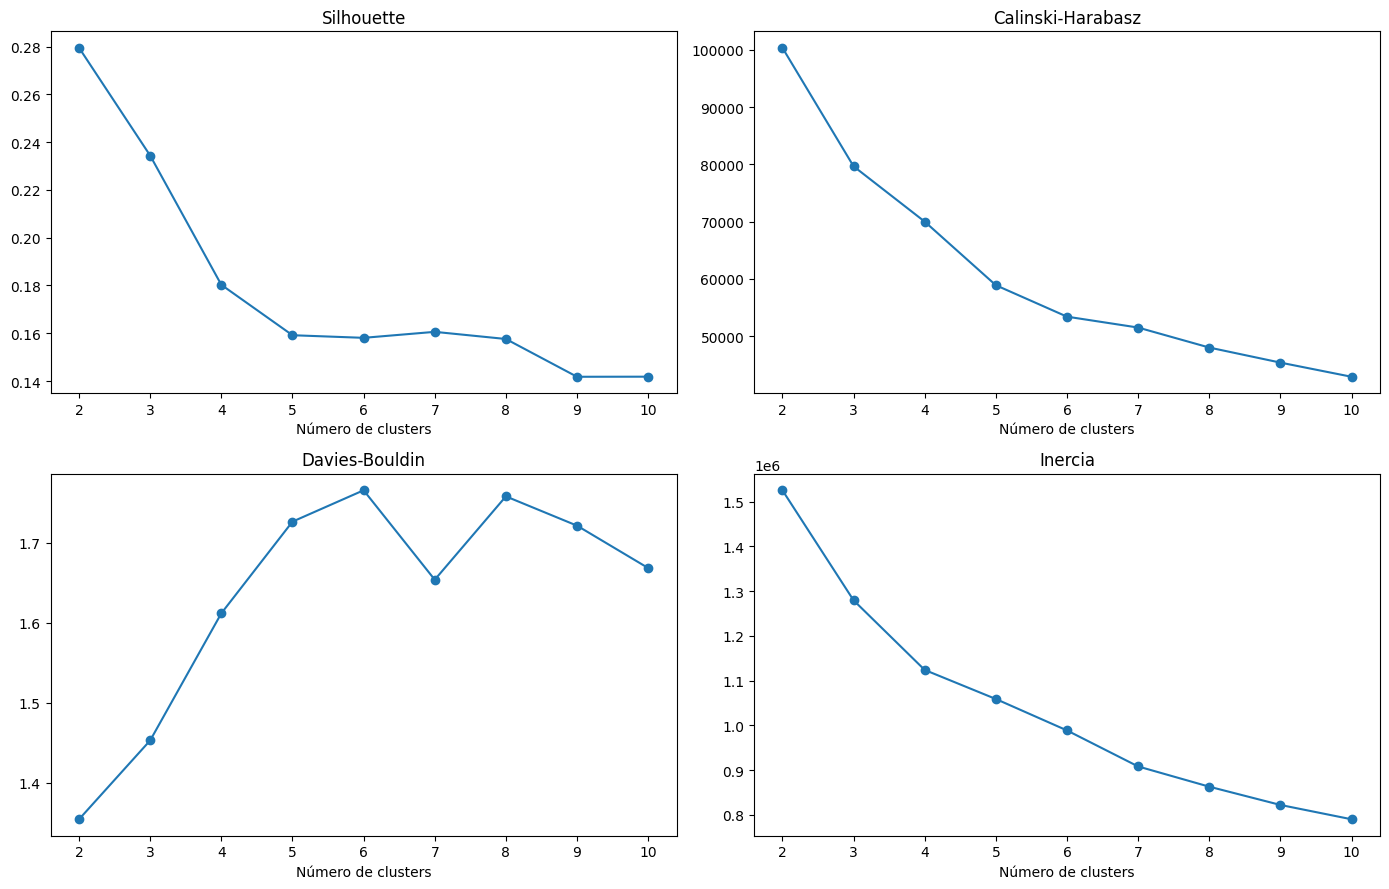

In [4]:
plot_clustering_metrics(
    resultados_bisecting,
    fourth_metric="inertia",
    fourth_title="Inercia",
)

## Ajuste final y perfil de los clusters


In [ ]:
modelo, labels = fit_clustering_model(
    model_name="bisecting",
    k=2,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="user_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0    110867
1     95342
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    53.76
1    46.24
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,avg_basket_size,std_basket_size,avg_days_between_orders,std_days_between_orders,unique_products,unique_aisles,unique_departments,reorder_ratio,product_variety_ratio
cluster,,,,,,,,,,,
0,21.123,6.775,7.898,3.387,15.970,11.354,30.654,17.406,8.582,0.322,0.678
1,12.340,25.842,12.339,5.289,10.473,7.298,103.936,39.851,13.440,0.561,0.439


- Cluster 0 - Clientes ocasionales y de baja vinculación (53,76%): muestran mayor recencia, baja frecuencia y cestas pequeñas. Compran menos productos y categorías y su tasa de recompra es reducida, mientras que el mayor ratio de variedad revela menor repetición relativa.
- Cluster 1 - Clientes frecuentes y recurrentes (46,24%): compran más recientemente, realizan casi cuatro veces más pedidos y forman cestas mayores. Presentan gran variedad absoluta y una elevada tasa de recompra, características propias de clientes consolidados.